## Telecom Customer Churn Prediction using Decision Trees

In [1]:
import pandas as pd
import numpy as np, seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, accuracy_score

In [2]:
df = pd.read_csv('train.csv')
df.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,OH,107,area_code_415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,no
1,NJ,137,area_code_415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,no
2,OH,84,area_code_408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,no
3,OK,75,area_code_415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,no
4,MA,121,area_code_510,no,yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4250 entries, 0 to 4249
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   state                          4250 non-null   object 
 1   account_length                 4250 non-null   int64  
 2   area_code                      4250 non-null   object 
 3   international_plan             4250 non-null   object 
 4   voice_mail_plan                4250 non-null   object 
 5   number_vmail_messages          4250 non-null   int64  
 6   total_day_minutes              4250 non-null   float64
 7   total_day_calls                4250 non-null   int64  
 8   total_day_charge               4250 non-null   float64
 9   total_eve_minutes              4250 non-null   float64
 10  total_eve_calls                4250 non-null   int64  
 11  total_eve_charge               4250 non-null   float64
 12  total_night_minutes            4250 non-null   f

In [4]:
df.describe()

,account_length,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
count,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000
mean,100.236235,7.631765,180.259600,99.907294,30.644682,200.173906,100.176471,17.015012,200.527882,99.839529,9.023892,10.256071,4.426353,2.769654,1.559059
std,39.698401,13.439882,54.012373,19.850817,9.182096,50.249518,19.908591,4.271212,50.353548,20.093220,2.265922,2.760102,2.463069,0.745204,1.311434
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,0.000000,143.325000,87.000000,24.365000,165.925000,87.000000,14.102500,167.225000,86.000000,7.522500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,0.000000,180.450000,100.000000,30.680000,200.700000,100.000000,17.060000,200.450000,100.000000,9.020000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,16.000000,216.200000,113.000000,36.750000,233.775000,114.000000,19.867500,234.700000,113.000000,10.560000,12.000000,6.000000,3.240000,2.000000
max,243.000000,52.000000,351.500000,165.000000,59.760000,359.300000,170.000000,30.540000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [6]:
df.dtypes

state                             object
account_length                     int64
area_code                         object
international_plan                object
voice_mail_plan                   object
number_vmail_messages              int64
total_day_minutes                float64
total_day_calls                    int64
total_day_charge                 float64
total_eve_minutes                float64
total_eve_calls                    int64
total_eve_charge                 float64
total_night_minutes              float64
total_night_calls                  int64
total_night_charge               float64
total_intl_minutes               float64
total_intl_calls                   int64
total_intl_charge                float64
number_customer_service_calls      int64
churn                             object
dtype: object

In [7]:
#deleting unncessary columns
df.drop(columns=['state', 'area_code'], inplace=True)

In [8]:
#converting all 'object' types to 'category' types, since they are all variables with levels
df['international_plan'] = df['international_plan'].astype('category')
df['voice_mail_plan'] = df['voice_mail_plan'].astype('category')
df['churn'] = df['churn'].astype('category')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4250 entries, 0 to 4249
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   account_length                 4250 non-null   int64   
 1   international_plan             4250 non-null   category
 2   voice_mail_plan                4250 non-null   category
 3   number_vmail_messages          4250 non-null   int64   
 4   total_day_minutes              4250 non-null   float64 
 5   total_day_calls                4250 non-null   int64   
 6   total_day_charge               4250 non-null   float64 
 7   total_eve_minutes              4250 non-null   float64 
 8   total_eve_calls                4250 non-null   int64   
 9   total_eve_charge               4250 non-null   float64 
 10  total_night_minutes            4250 non-null   float64 
 11  total_night_calls              4250 non-null   int64   
 12  total_night_charge             425

In [12]:
#converting category variables into numerical values
catg_columns = df.select_dtypes(['category']).columns
df[catg_columns] = df[catg_columns].apply(lambda x: x.cat.codes)

df.head()

,account_length,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
1,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
2,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
3,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
4,121,0,1,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,0


In [13]:
# Split data into X and y
X = df.drop(['churn'], axis=1)
y = df['churn']

In [14]:
# split the data into training and test datasets in ratio of 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=100)

In [19]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, export_graphviz

In [20]:
#building decision tree model
clf = DecisionTreeClassifier(random_state=100)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=100)

In [24]:
from IPython.display import Image
import pydotplus

In [25]:
#make predictions on training dataset
y_train_pred = clf.predict(X_train)

#calculating accuracy score
train_score = accuracy_score(y_train, y_train_pred)

In [26]:
print(train_score)

1.0


In [27]:
#predicting on test dataset and calculating accuracy score
y_test_pred = clf.predict(X_test)
test_score = accuracy_score(y_test, y_test_pred)
print(test_score)

0.9219190968955786


#### Since the dataset has an accuracy score of 1 on training dataset, i.e., 100%, there could have been a chance that the model overfitted the data. To avoid this, we can pre-prune the tree, that is, limit the depth of the tree so that it does not overfit.

In [28]:
#building another tree with depth 4
clf1 = DecisionTreeClassifier(max_depth=4, random_state=100)
clf1.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=100)

In [29]:
#make predictions on training dataset
y_train_pred = clf1.predict(X_train)

#calculating accuracy score
train_score = accuracy_score(y_train, y_train_pred)
print(train_score)

0.9309695638531534


In [30]:
#predicting on test dataset and calculating accuracy score
y_test_pred = clf1.predict(X_test)
test_score = accuracy_score(y_test, y_test_pred)
print(test_score)

0.9313264346190028


#### We can see that controlling the depth of the tree has decreased the accuracy of the tarining data, but has increased accuracy of test data.

#### Similarly, let's do further hyperparameter tuning to see if we can achieve a better model.

In [40]:
#building another tree with depth 7, min_samples_split=5 & min_samples_leaf=5
clf2 = DecisionTreeClassifier(max_depth=7, min_samples_split=5, min_samples_leaf=5, random_state=100)
clf2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, min_samples_leaf=5, min_samples_split=5,
                       random_state=100)

In [41]:
#make predictions on training dataset
y_train_pred = clf2.predict(X_train)

#calculating accuracy score
train_score = accuracy_score(y_train, y_train_pred)
print(train_score)

0.9623470348289928


In [42]:
#predicting on test dataset and calculating accuracy score
y_test_pred = clf2.predict(X_test)
test_score = accuracy_score(y_test, y_test_pred)
print(test_score)

0.9501411100658513


In [68]:
#also calculating precision and recall 
precision_metric = precision_score(y_test, y_test_pred, average = "macro")
recall_metric = recall_score(y_test, y_test_pred, average = "macro")

print('Precision :', precision_metric)
print('Recall :', recall_metric)

Precision : 0.9214252445272473
Recall : 0.8501006036217305


#### We can see that accuracy scores of both training and test data have imporved significantly using the 'clf2' model, due to hyperparameter tuning.

#### Let's use this model to predict on 'test.csv' and evaluate its performance.

In [43]:
df_test = pd.read_csv('test.csv')
df_test.head()

,id,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
0,1,KS,128,area_code_415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,2,AL,118,area_code_510,yes,no,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0
2,3,IA,62,area_code_415,no,no,0,120.7,70,20.52,307.2,76,26.11,203.0,99,9.14,13.1,6,3.54,4
3,4,VT,93,area_code_510,no,no,0,190.7,114,32.42,218.2,111,18.55,129.6,121,5.83,8.1,3,2.19,3
4,5,NE,174,area_code_415,no,no,0,124.3,76,21.13,277.1,112,23.55,250.7,115,11.28,15.5,5,4.19,3


In [44]:
df_test.drop(columns=['state', 'area_code'], inplace=True)

In [47]:
df_test.dtypes

id                                 int64
account_length                     int64
international_plan                object
voice_mail_plan                   object
number_vmail_messages              int64
total_day_minutes                float64
total_day_calls                    int64
total_day_charge                 float64
total_eve_minutes                float64
total_eve_calls                    int64
total_eve_charge                 float64
total_night_minutes              float64
total_night_calls                  int64
total_night_charge               float64
total_intl_minutes               float64
total_intl_calls                   int64
total_intl_charge                float64
number_customer_service_calls      int64
dtype: object

In [48]:
df_test.head()

,id,account_length,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
0,1,128,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,2,118,yes,no,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0
2,3,62,no,no,0,120.7,70,20.52,307.2,76,26.11,203.0,99,9.14,13.1,6,3.54,4
3,4,93,no,no,0,190.7,114,32.42,218.2,111,18.55,129.6,121,5.83,8.1,3,2.19,3
4,5,174,no,no,0,124.3,76,21.13,277.1,112,23.55,250.7,115,11.28,15.5,5,4.19,3


In [50]:
#converting all 'object' types to 'category' types, since they are all variables with levels
df_test['international_plan'] = df_test['international_plan'].astype('category')
df_test['voice_mail_plan'] = df_test['voice_mail_plan'].astype('category')

In [51]:
df_test.dtypes

id                                  int64
account_length                      int64
international_plan               category
voice_mail_plan                  category
number_vmail_messages               int64
total_day_minutes                 float64
total_day_calls                     int64
total_day_charge                  float64
total_eve_minutes                 float64
total_eve_calls                     int64
total_eve_charge                  float64
total_night_minutes               float64
total_night_calls                   int64
total_night_charge                float64
total_intl_minutes                float64
total_intl_calls                    int64
total_intl_charge                 float64
number_customer_service_calls       int64
dtype: object

In [52]:
#converting category variables into numerical values
catg_columns = df_test.select_dtypes(['category']).columns
df_test[catg_columns] = df_test[catg_columns].apply(lambda x: x.cat.codes)

df_test.head()

,id,account_length,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
0,1,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,2,118,1,0,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0
2,3,62,0,0,0,120.7,70,20.52,307.2,76,26.11,203.0,99,9.14,13.1,6,3.54,4
3,4,93,0,0,0,190.7,114,32.42,218.2,111,18.55,129.6,121,5.83,8.1,3,2.19,3
4,5,174,0,0,0,124.3,76,21.13,277.1,112,23.55,250.7,115,11.28,15.5,5,4.19,3


In [53]:
df_test.drop('id', axis=1, inplace=True)

In [54]:
df_test.head()

,account_length,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,118,1,0,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0
2,62,0,0,0,120.7,70,20.52,307.2,76,26.11,203.0,99,9.14,13.1,6,3.54,4
3,93,0,0,0,190.7,114,32.42,218.2,111,18.55,129.6,121,5.83,8.1,3,2.19,3
4,174,0,0,0,124.3,76,21.13,277.1,112,23.55,250.7,115,11.28,15.5,5,4.19,3


In [62]:
# No need of splitting data into X and y, since there is no target variable 'churn' here in test.csv
X = df_test

#all data becomes X, the features
print("Features (X):")
print(X.columns)

Features (X):
Index(['account_length', 'international_plan', 'voice_mail_plan',
       'number_vmail_messages', 'total_day_minutes', 'total_day_calls',
       'total_day_charge', 'total_eve_minutes', 'total_eve_calls',
       'total_eve_charge', 'total_night_minutes', 'total_night_calls',
       'total_night_charge', 'total_intl_minutes', 'total_intl_calls',
       'total_intl_charge', 'number_customer_service_calls'],
      dtype='object')


In [63]:
# Make predictions using the pre-trained model
y_pred = clf2.predict(X)

# Output the predictions
print("Predictions:", y_pred)

Predictions: [0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0
 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0
 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 1 1 0 0 1 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 1
 0 0 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0

In [64]:
type(y_pred)

numpy.ndarray

In [65]:
#converting y_pred into dataframe
output_churn = pd.DataFrame(y_pred, columns=['churn'])
output_churn.head()

,churn
0,0
1,0
2,1
3,0
4,0


In [66]:
#appendinf churn output with original test.csv df
final_df = pd.concat([df_test, output_churn], axis=1)
final_df.head()

,account_length,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,118,1,0,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,0
2,62,0,0,0,120.7,70,20.52,307.2,76,26.11,203.0,99,9.14,13.1,6,3.54,4,1
3,93,0,0,0,190.7,114,32.42,218.2,111,18.55,129.6,121,5.83,8.1,3,2.19,3,0
4,174,0,0,0,124.3,76,21.13,277.1,112,23.55,250.7,115,11.28,15.5,5,4.19,3,0


In [67]:
#exporting output to a csv file
final_df.to_csv('test_output.csv', index=False)

#### In this way, we used our already trained decision tree model (clf2) on new data (test.csv), and made predictions. 

#### This will help the telecom company in knowing which customers are about to leave, to take any preventive measures.

## Feature Selection

In [69]:
f_imp = clf2.feature_importances_
print(f"Feature Importance:\n{f_imp}") 

Feature Importance:
[0.         0.08161679 0.08440844 0.00057099 0.05073204 0.00478527
 0.2940566  0.06540679 0.         0.03684025 0.02686227 0.00289791
 0.03248156 0.00523572 0.07984878 0.09800038 0.13625621]


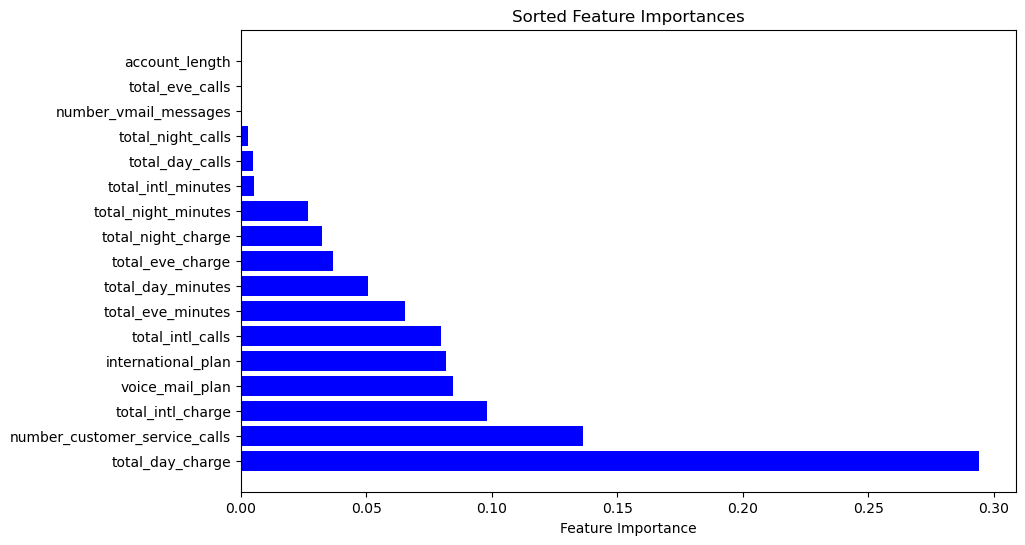

In [72]:
feature_names = df.columns

# Sort the feature importances and corresponding feature names
sorted_idx = np.argsort(f_imp)[::-1]  # Sort in descending order

# Sort feature names and importances
sorted_features = np.array(feature_names)[sorted_idx]
sorted_importances = f_imp[sorted_idx]

# Plot the sorted feature importances
plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances, color='blue')
plt.xlabel('Feature Importance')
plt.title('Sorted Feature Importances')
plt.show()

#### The above plot shows the importance of features in ascending order, based on their contribution to customer churn rate. We can see that 'total_day_charge' is the most important feature contributing to customer churn rate.